In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pairs_trading.data.loaders import load_prices
from pairs_trading.config import SplitConfig, KalmanConfig, SignalConfig
from pairs_trading.models.ols_hedge import OLSHedge
from pairs_trading.models.kalman_hedge import KalmanHedge
from pairs_trading.signals.zscore import rolling_zscore, generate_signal, garch_zscore
from pairs_trading.backtest.engine import BacktestEngine
from pairs_trading.stats.garch import GARCHVolatility, compute_position_sizes
from statsmodels.graphics.tsaplots import plot_acf

In [2]:
tickers = ["IAU", "GDX", "GLD", "SLV", "XLF", "KBE", "SPY", "IVV"]
df_train = load_prices(tickers, SplitConfig.train_start, SplitConfig.train_end, refresh=True)
df_test = load_prices(tickers, SplitConfig.val_start, SplitConfig.val_end, refresh=True)

[*********************100%***********************]  8 of 8 completed
[*********************100%***********************]  8 of 8 completed


In [3]:
pairs = [["IAU", "GDX"],["GLD", "SLV"], ["XLF", "KBE"], ["SPY", "IVV"]]

First we fit the GARCH model on the residuals and depict the evolution of the fitted volantility as well as what effect factoring out the volantility has on the ACF of the squared residuals

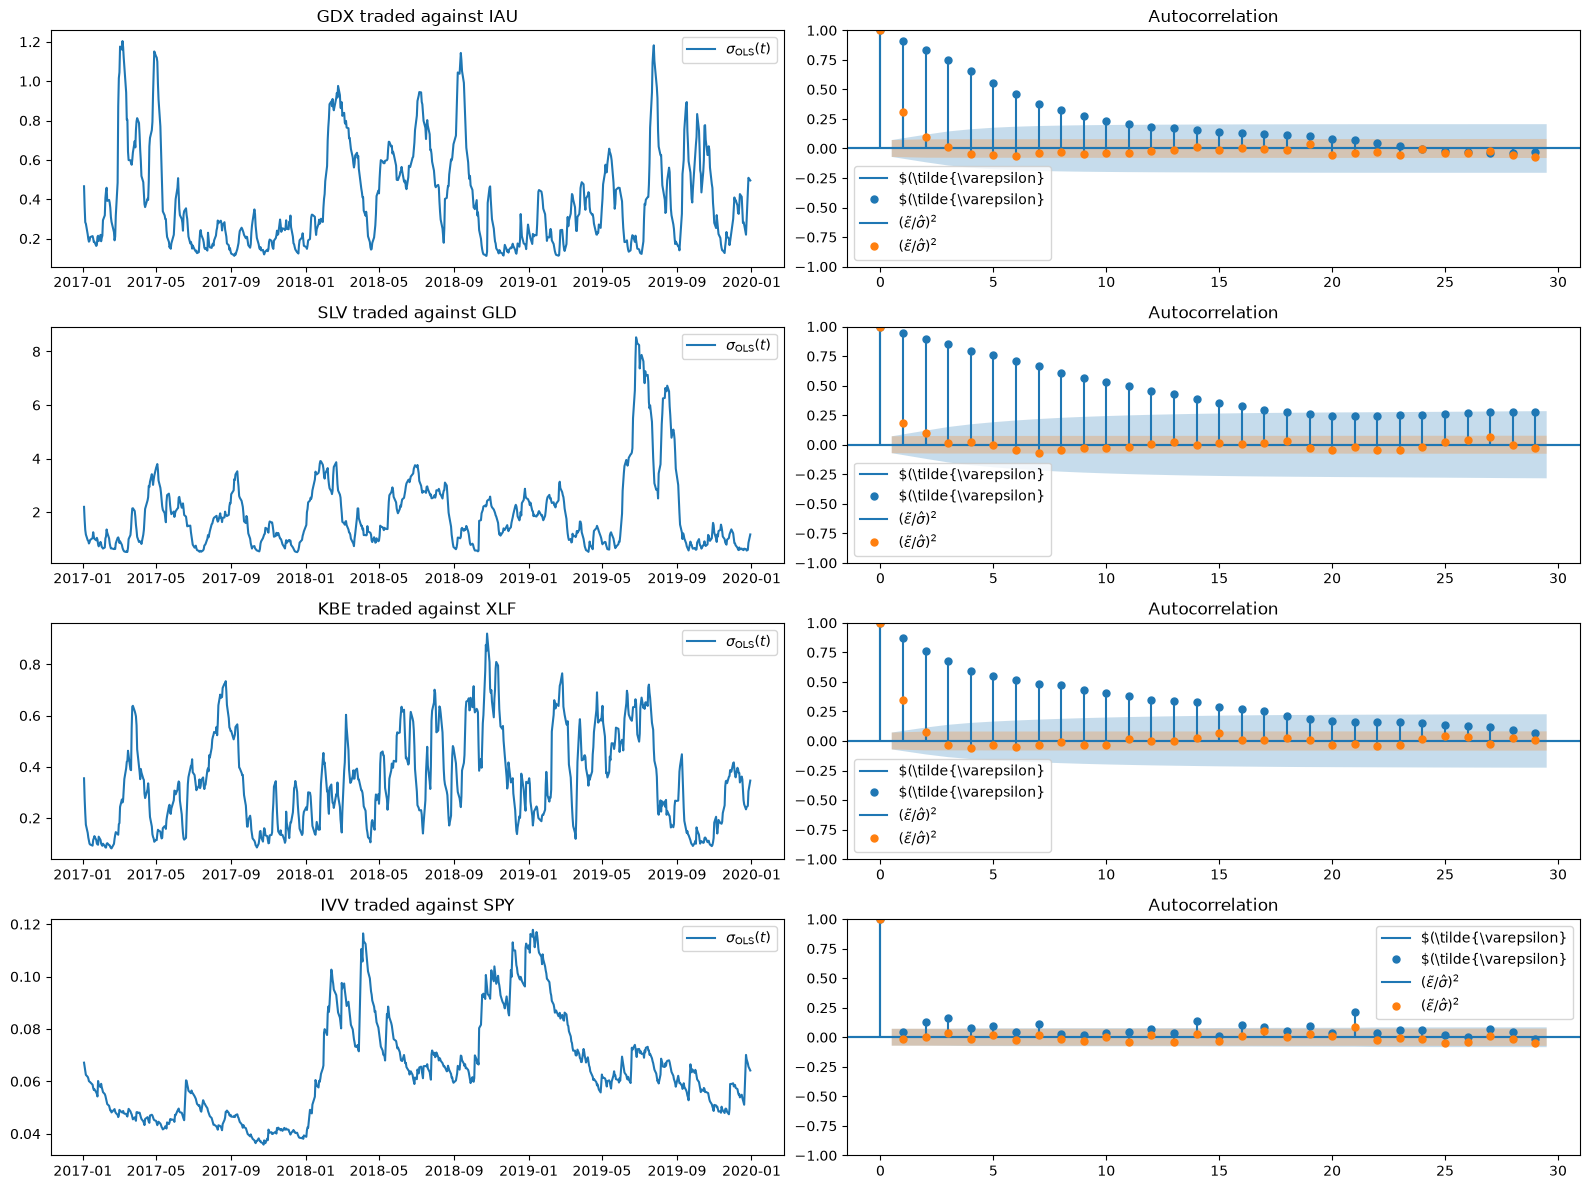

In [16]:
fig, axs = plt.subplots(nrows=4, ncols=2, figsize=(16,12))
for i, (y, x) in enumerate(pairs):
    ols = OLSHedge()
    ols.fit(df_train[y], df_train[x])
    res_ols = ols.spread(df_train[y], df_train[x])

    
    garch = GARCHVolatility()
    garch.fit(res_ols)

    axs[i, 0].set_title(f"{x} traded against {y}")
    axs[i, 0].plot(garch.sigma_t, label=r"$\sigma_\mathrm{OLS}(t)$")
    axs[i,0].legend()

    plot_acf(garch._demeaned**2, ax = axs[i, 1], label = r"$(\tilde{\varepsilon}")

    plot_acf((garch._demeaned/garch.sigma_t)**2, ax = axs[i, 1], label = r"$(\tilde{\varepsilon}/\hat{\sigma})^2$")
    axs[i,1].legend()

plt.tight_layout()
plt.show()

The first thing we see is the large spike on the Kalman volantility which is just the secondary effect of the delay in the convergence of the Kalman hedging factor. After conversion the volantility remains quite noisy. As expected COVID created a volantility spike in all pairs. For XLE and OIH the affect is quite small reflecting that they were hit by the COVID shock in a very similar way.

We also see that the GARCH model is very able to erase the autocorrelation in the squared residuals in the OLS model. Kalman does not show much autocorrelation in the first place as it is mostly absorbed by the hedge ratio. 

Next we investigate the PnL values for the base OLS and Kalman configuration as well as in combination with GARCH determined z-values and position_weighting

Next we perform a grid search on entry exit and 

In [12]:
grid = {"entry_z" : [1.5, 2.0, 2.5, 3.0],
"exit_z" : [0.5, 0.2, 0.0],
"stop_z" : [3.0, 3.5, 4.0, 4.5, 5.0],
"max_holding" : [5, 10, 20, 30, 40, 50, 400],
"pair": pairs}

import itertools
keys, values = zip(*grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
df_grid = pd.DataFrame(combinations)
df_grid['sharpe_ols'] = np.zeros(len(df_grid))
df_grid['sharpe_kalman'] = np.zeros(len(df_grid))
df_grid['sharpe_ols_with_garch_vol'] = np.zeros(len(df_grid))
df_grid['sharpe_kalman_with_garch_vol'] = np.zeros(len(df_grid))
df_grid['sharpe_ols_with_garch_pos'] = np.zeros(len(df_grid))
df_grid['sharpe_kalman_with_garch_pos'] = np.zeros(len(df_grid))


First let's fit the data and make the prediction as this part is SignalConfig independent.

In [ ]:
pair_data = {}
for y, x in pairs:
    ols = OLSHedge()
    ols.fit(df_train[y], df_train[x])
    res_ols_train = ols.residuals
    res_ols_test = ols.spread(df_test[y], df_test[x])
    ols_beta = pd.Series(ols.beta, index=res_ols_test.index)

    garch = GARCHVolatility()
    garch.fit(res_ols_train)
    cond_vol = garch.transform(res_ols_test)

    hedge_kalman = KalmanHedge()
    hedge_kalman.fit(df_train[y], df_train[x])
    kalman_beta, _, _ = hedge_kalman.transform(df_test[y], df_test[x])


    zscores = rolling_zscore(res_ols_test)

    zscores_garch = garch_zscore(res_ols_test, cond_vol)

    pos_sizes = compute_position_sizes(cond_vol)
    
    pair_data[(y, x)] = {
        "ols_beta": ols_beta,
        "kalman_beta": kalman_beta,
        "zscores": zscores,
        "zscores_garch": zscores_garch,
        "pos_sizes": pos_sizes,
    }


IAU/GDX:  rolling_std=0.6699  cond_vol=0.7756  ratio=1.16x
GLD/SLV:  rolling_std=2.9076  cond_vol=3.3917  ratio=1.17x
XLF/KBE:  rolling_std=0.5432  cond_vol=0.6491  ratio=1.19x
SPY/IVV:  rolling_std=0.0908  cond_vol=0.0948  ratio=1.04x


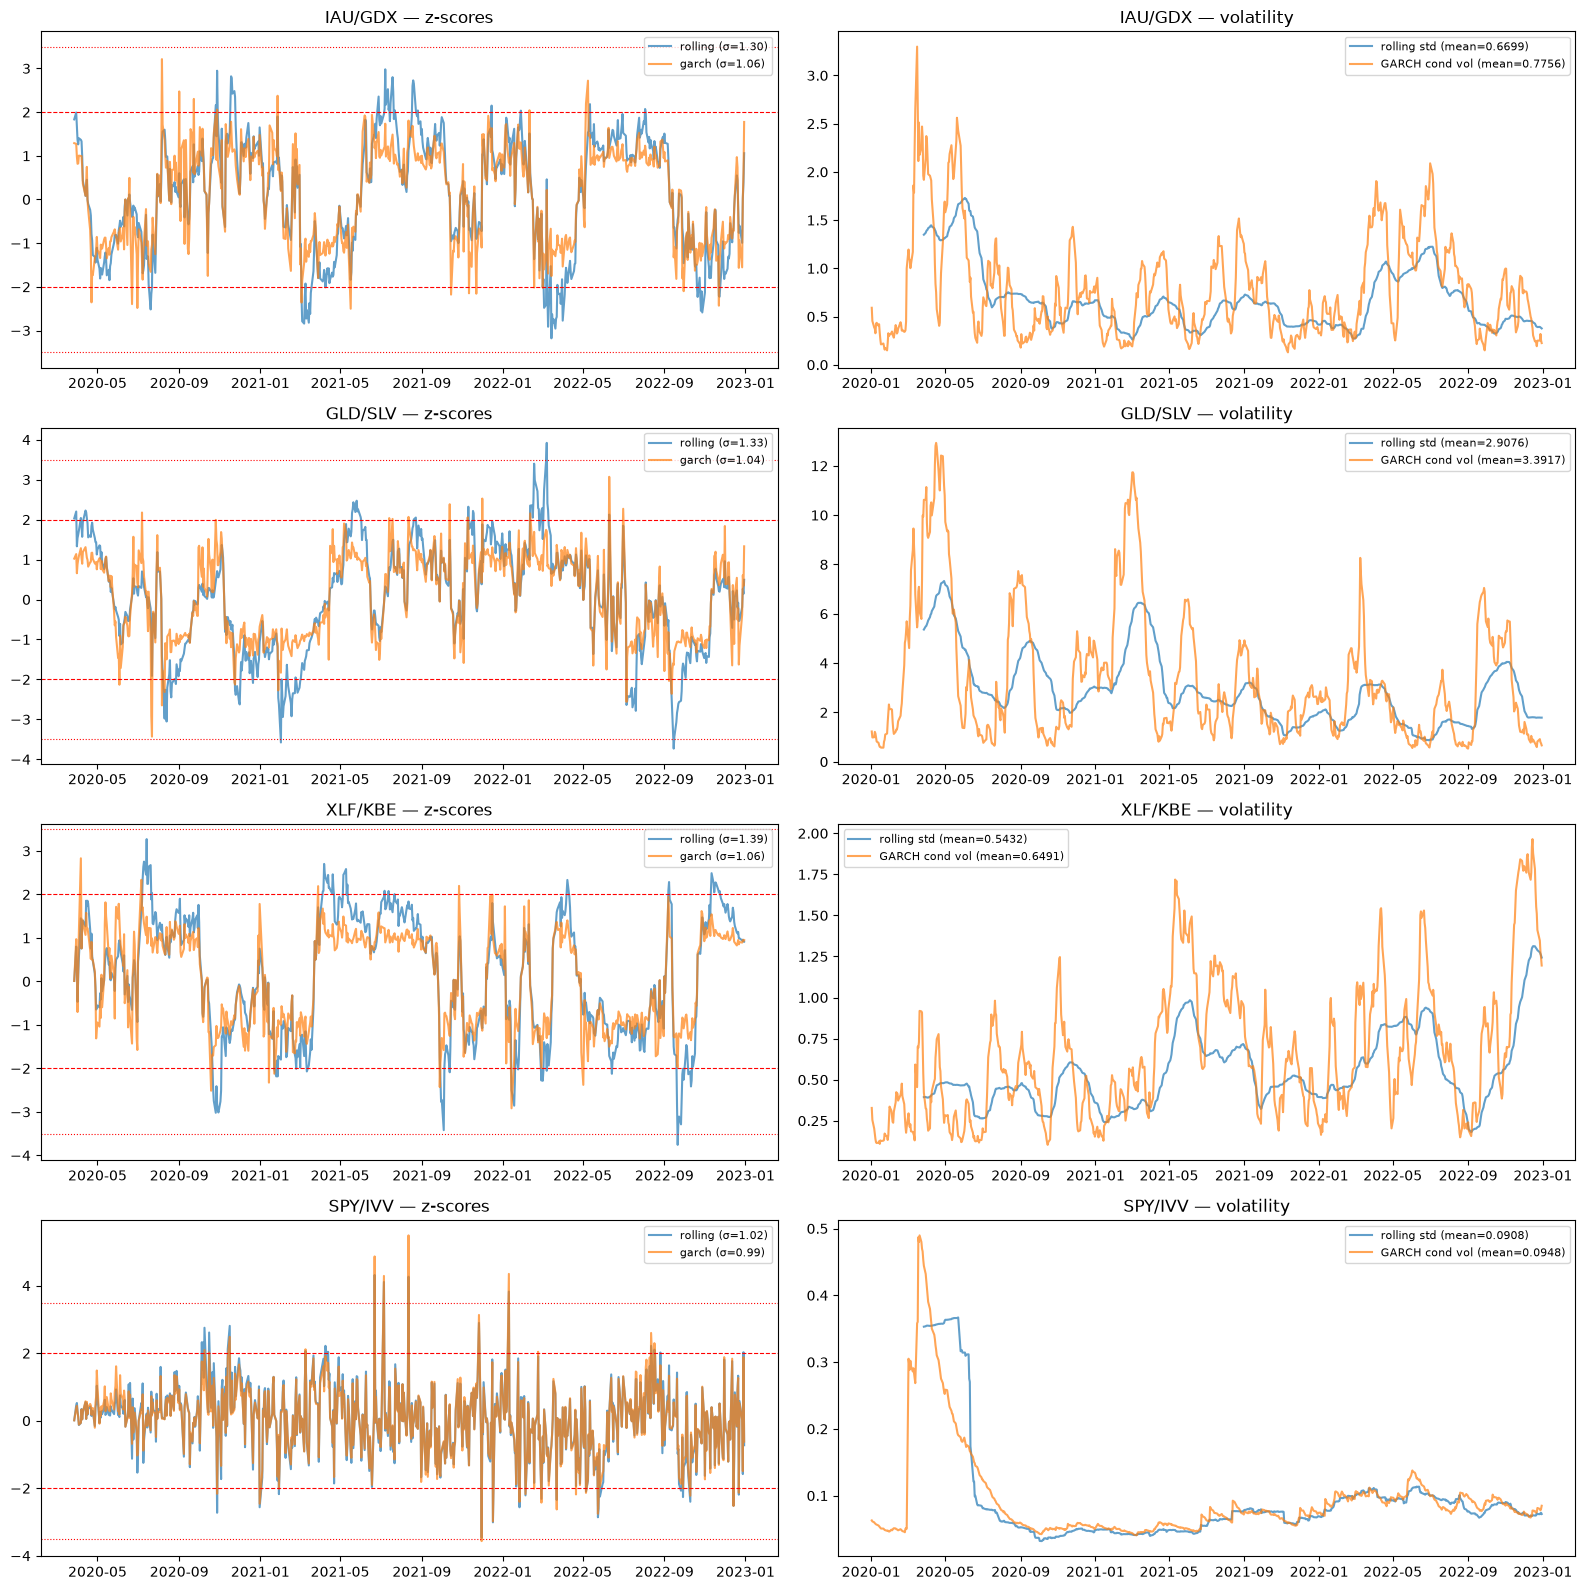

In [14]:
fig, axes = plt.subplots(4, 2, figsize=(16, 16))

for row, (y, x) in enumerate(pairs):
    ols = OLSHedge()
    ols.fit(df_train[y], df_train[x])
    res_ols_train = ols.residuals
    res_ols_test = ols.spread(df_test[y], df_test[x])

    garch = GARCHVolatility()
    garch.fit(res_ols_train)

    cond_vol = garch.transform(res_ols_test)

    rolling_std = res_ols_test.rolling(60).std()
    zscores = rolling_zscore(res_ols_test)
    zscores_garch = garch_zscore(res_ols_test, cond_vol)

    ax_z, ax_v = axes[row, 0], axes[row, 1]

    # Z-scores
    ax_z.plot(zscores, label=f"rolling (σ={zscores.std():.2f})", alpha=0.7)
    ax_z.plot(zscores_garch, label=f"garch (σ={zscores_garch.std():.2f})", alpha=0.7)
    for lvl, ls in [(2.0, '--'), (3.5, ':')]:
        ax_z.axhline(lvl, color='r', ls=ls, lw=0.8)
        ax_z.axhline(-lvl, color='r', ls=ls, lw=0.8)
    ax_z.set_title(f"{y}/{x} — z-scores")
    ax_z.legend(fontsize=8)

    # Volatilities
    ax_v.plot(rolling_std, label=f"rolling std (mean={rolling_std.mean():.4f})", alpha=0.7)
    ax_v.plot(cond_vol, label=f"GARCH cond vol (mean={cond_vol.mean():.4f})", alpha=0.7)
    ax_v.set_title(f"{y}/{x} — volatility")
    ax_v.legend(fontsize=8)

    print(f"{y}/{x}:  rolling_std={rolling_std.mean():.4f}  cond_vol={cond_vol.mean():.4f}  ratio={cond_vol.mean()/rolling_std.mean():.2f}x")

plt.tight_layout()
plt.show()

In [ ]:
for i, conf in df_grid.iterrows():
    pair = conf.pair
    y, x = pair[0], pair[1]
    ols_beta =  pair_data[tuple(pair)]["ols_beta"]
    kalman_beta =  pair_data[tuple(pair)]["kalman_beta"]
    zscores =  pair_data[tuple(pair)]["zscores"]
    zscores_garch =  pair_data[tuple(pair)]["zscores_garch"]
    pos_sizes =  pair_data[tuple(pair)]["pos_sizes"]

    signal_config = SignalConfig(entry_z=conf.entry_z, exit_z=conf.exit_z, stop_z = conf.stop_z, max_holding=conf.max_holding)

    signals = generate_signal(zscores, signal_config)
    signals_garch = generate_signal(zscores_garch, signal_config)

    engine_ols = BacktestEngine()
    result_ols = engine_ols.run(df_test[y], df_test[x], signals, ols_beta, max_holding=signal_config.max_holding)
    engine_kalman = BacktestEngine()
    result_kalman = engine_kalman.run(df_test[y], df_test[x], signals, kalman_beta, max_holding=signal_config.max_holding)

    engine_ols_garch = BacktestEngine()
    result_ols_garch = engine_ols_garch.run(df_test[y], df_test[x], signals_garch, ols_beta, max_holding=signal_config.max_holding)
    engine_kalman_garch = BacktestEngine()
    result_kalman_garch = engine_kalman_garch.run(df_test[y], df_test[x], signals_garch, kalman_beta, max_holding=signal_config.max_holding)

    engine_ols_garch_pos = BacktestEngine()
    result_ols_garch_pos = engine_ols_garch_pos.run(df_test[y], df_test[x], signals_garch, ols_beta, max_holding=signal_config.max_holding, position_sizes=pos_sizes)
    engine_kalman_garch_pos = BacktestEngine()
    result_kalman_garch_pos = engine_kalman_garch_pos.run(df_test[y], df_test[x], signals_garch, kalman_beta, max_holding=signal_config.max_holding, position_sizes=pos_sizes)

    df_grid.loc[i, 'sharpe_ols'] = result_ols.metrics['sharpe']
    df_grid.loc[i, 'sharpe_kalman'] = result_kalman.metrics['sharpe']
    df_grid.loc[i, 'sharpe_ols_with_garch_vol'] = result_ols_garch.metrics['sharpe']
    df_grid.loc[i, 'sharpe_kalman_with_garch_vol'] = result_kalman_garch.metrics['sharpe']
    df_grid.loc[i, 'sharpe_ols_with_garch_pos'] = result_ols_garch_pos.metrics['sharpe']
    df_grid.loc[i, 'sharpe_kalman_with_garch_pos'] = result_kalman_garch_pos.metrics['sharpe']

### Without GARCH volantility estimates

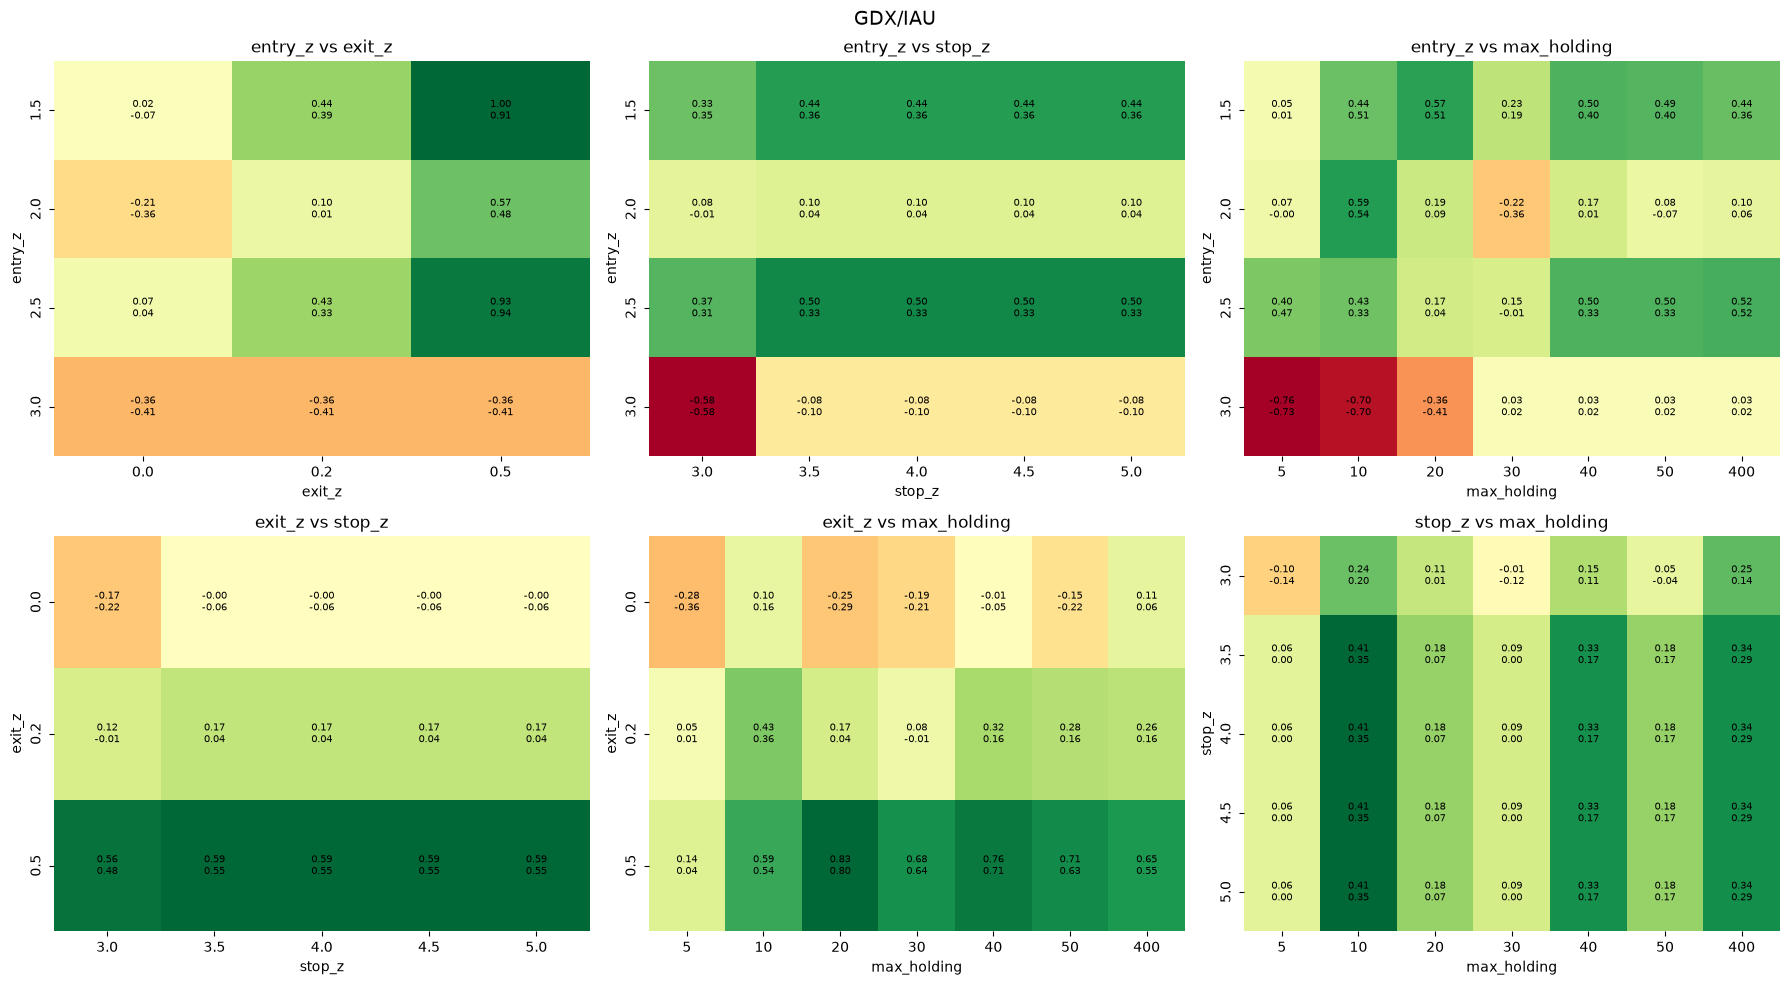

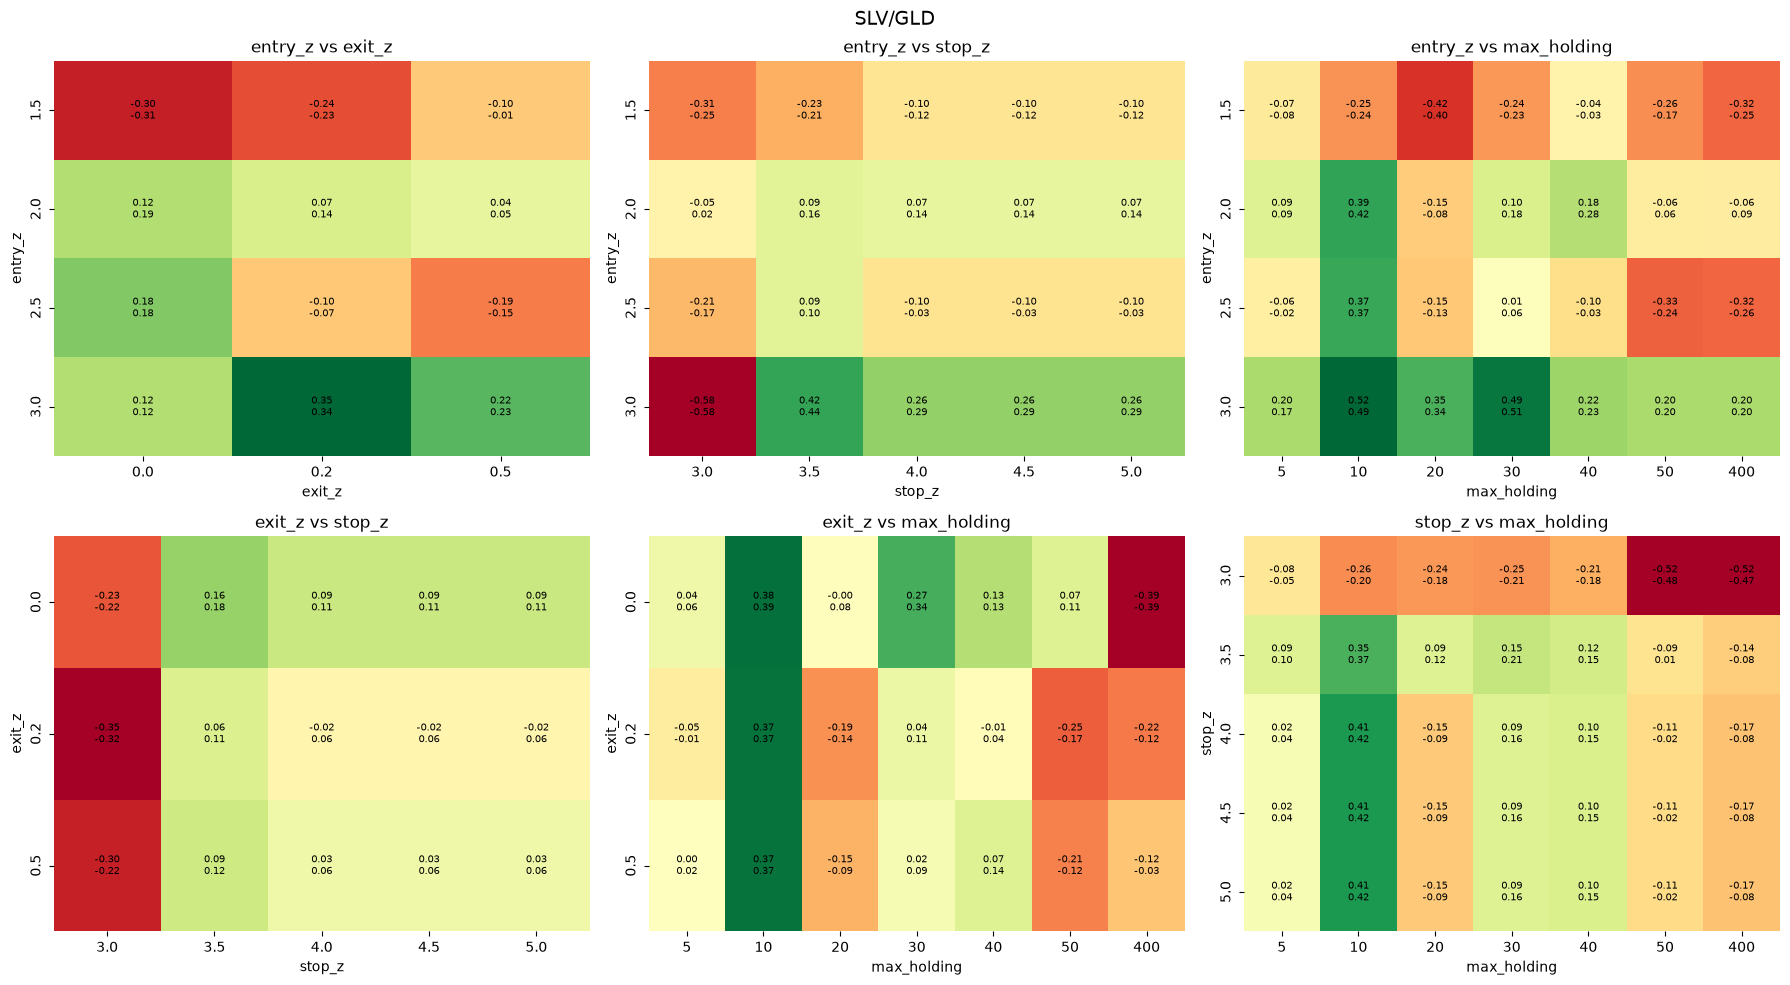

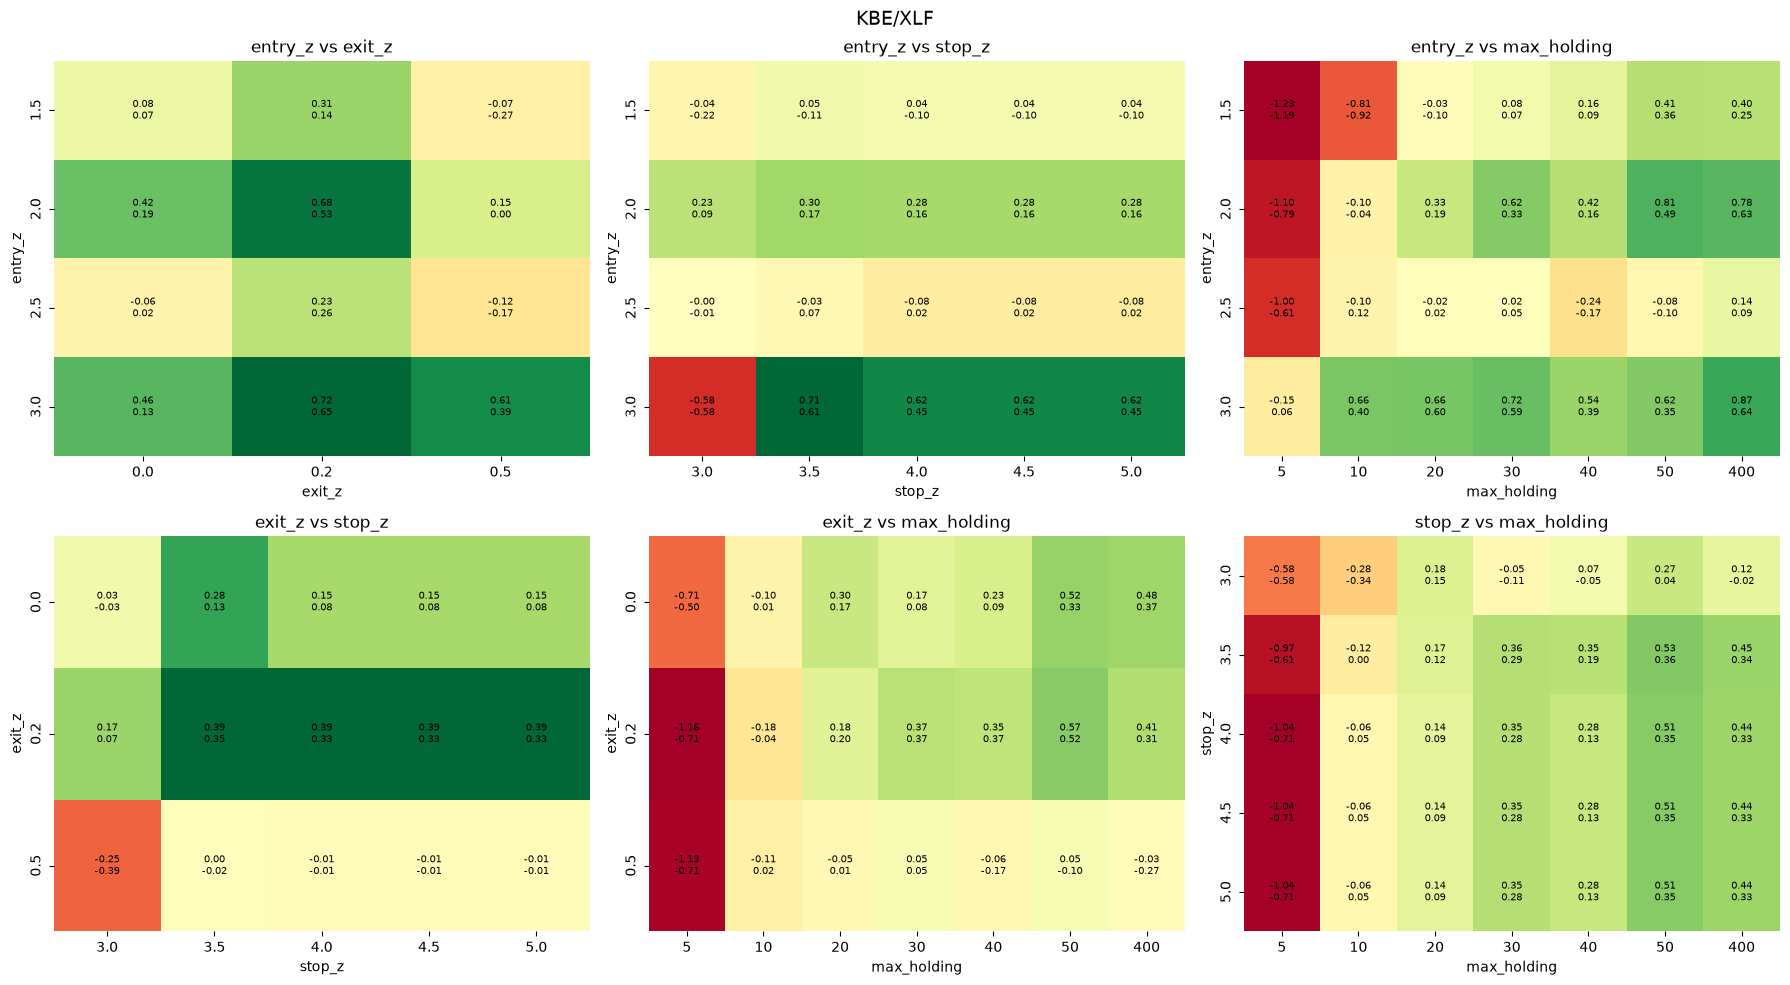

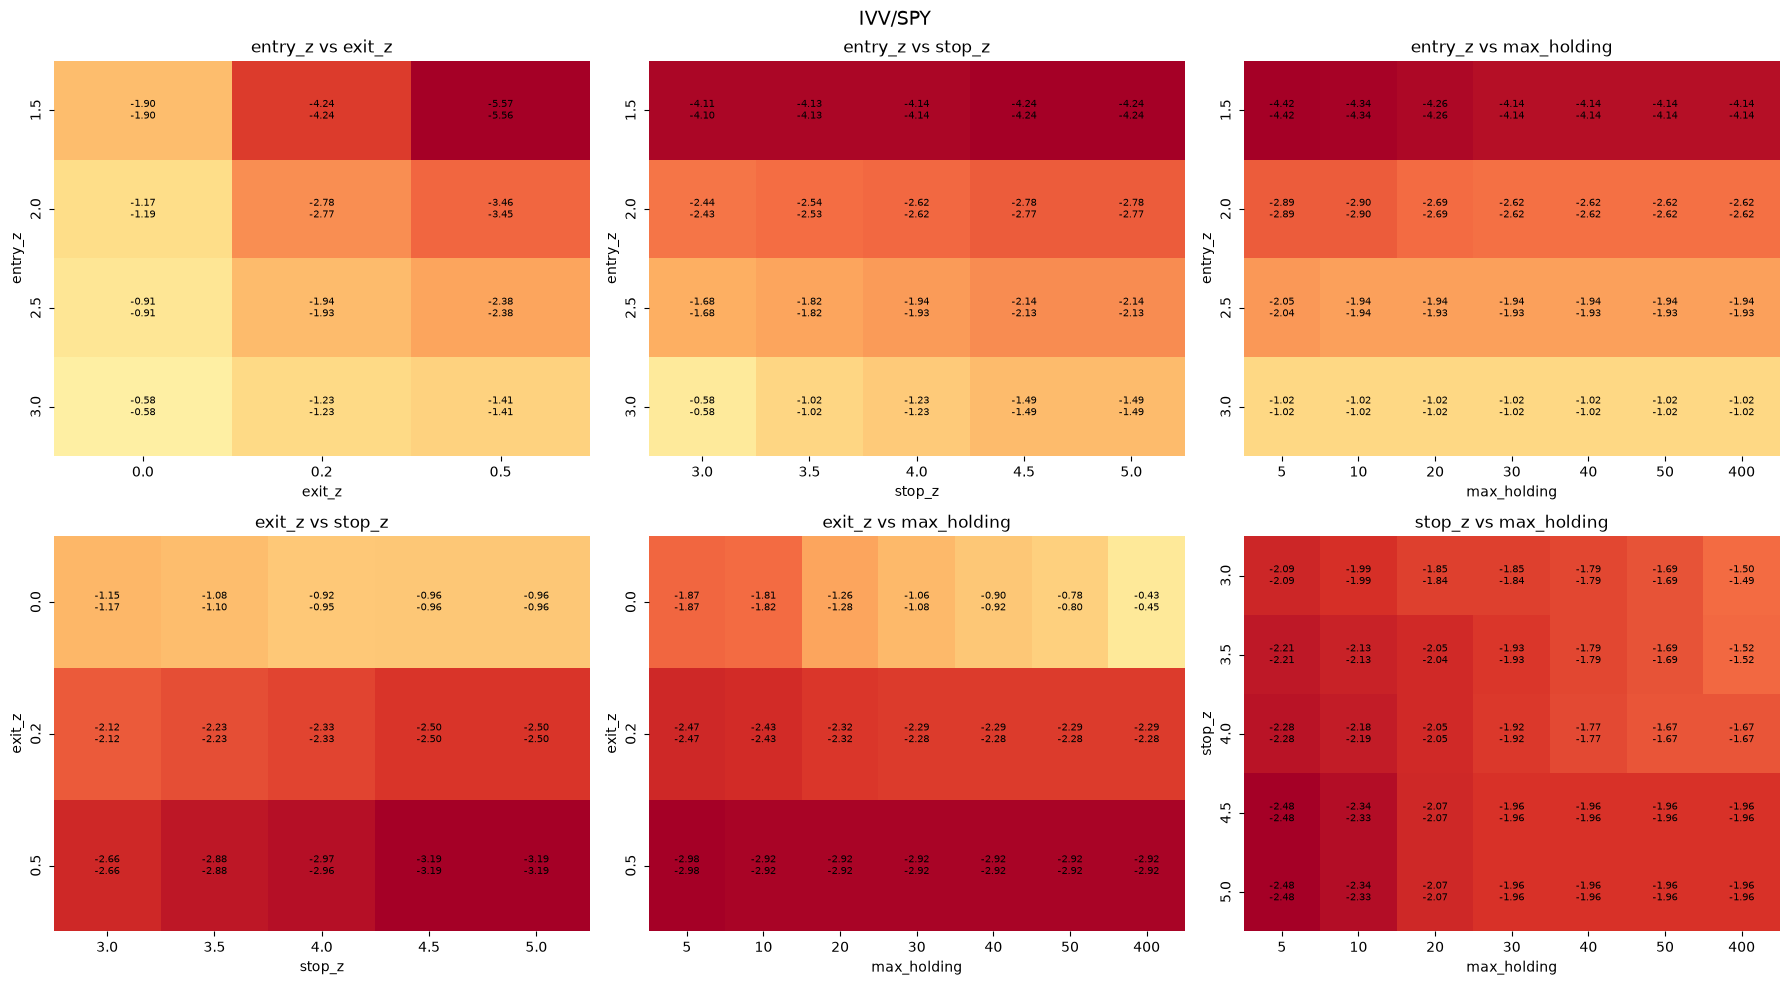

In [24]:
import seaborn as sns
from itertools import combinations

params = ["entry_z", "exit_z", "stop_z", "max_holding"]
strategies = [("sharpe_ols", "OLS"), ("sharpe_kalman", "Kalman")]
param_pairs = list(combinations(params, 2))  # 6 combinations

for y_pair, x_pair in [("IAU", "GDX"), ("GLD", "SLV"), ("XLF", "KBE"), ("SPY", "IVV")]:
    subset = df_grid[df_grid["pair"].apply(tuple) == (y_pair, x_pair)]
    
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    axs = axs.flatten()
    fig.suptitle(f"{x_pair}/{y_pair}", fontsize=14)
    
    for ax, (p1, p2) in zip(axs, param_pairs):
        # Aggregate over remaining params by taking median
        pivot_ols = subset.groupby([p1, p2])["sharpe_ols"].median().unstack(p2)
        pivot_kalman = subset.groupby([p1, p2])["sharpe_kalman"].median().unstack(p2)
        
        # Color by OLS Sharpe
        sns.heatmap(pivot_ols, ax=ax, cmap="RdYlGn", center=0, annot=False, cbar=False)
        
        # Annotate with both values
        for i, row in enumerate(pivot_ols.index):
            for j, col in enumerate(pivot_ols.columns):
                ols_val = pivot_ols.loc[row, col]
                kal_val = pivot_kalman.loc[row, col]
                ax.text(j+0.5, i+0.5, f"{ols_val:.2f}\n{kal_val:.2f}",
                        ha='center', va='center', fontsize=7)
        
        ax.set_title(f"{p1} vs {p2}")
    
    plt.tight_layout()
    plt.show()

### With GARCH volantility and position sizing

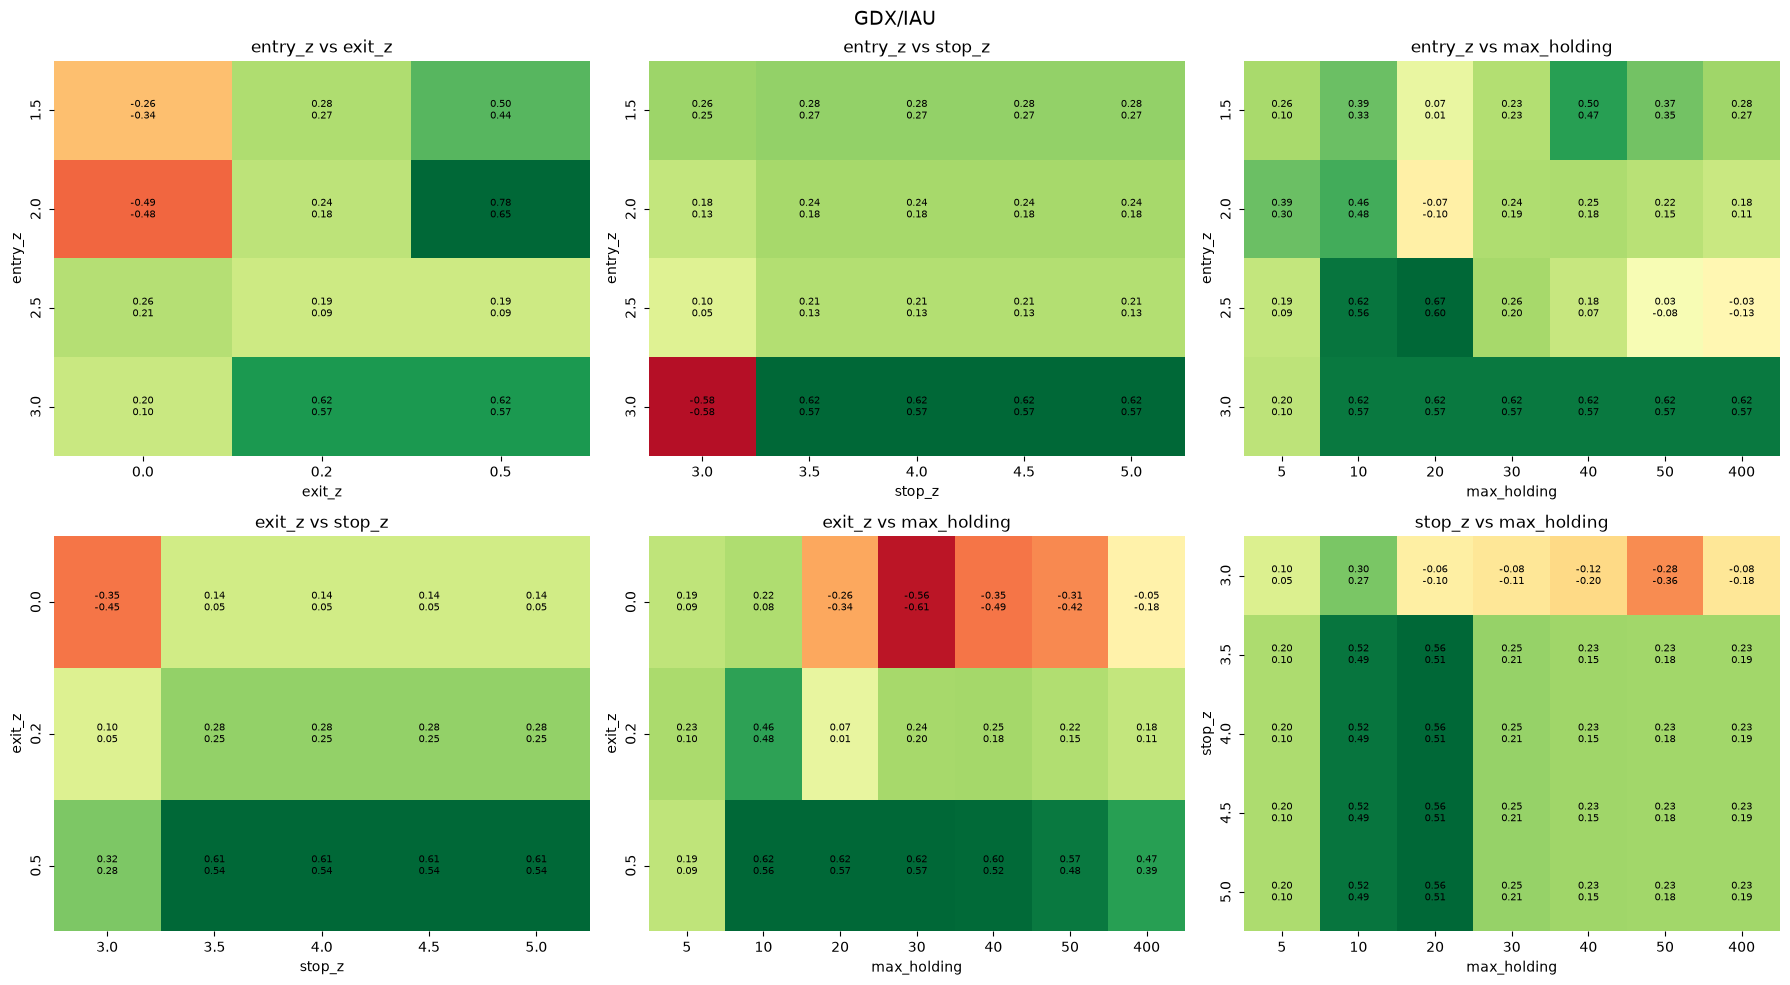

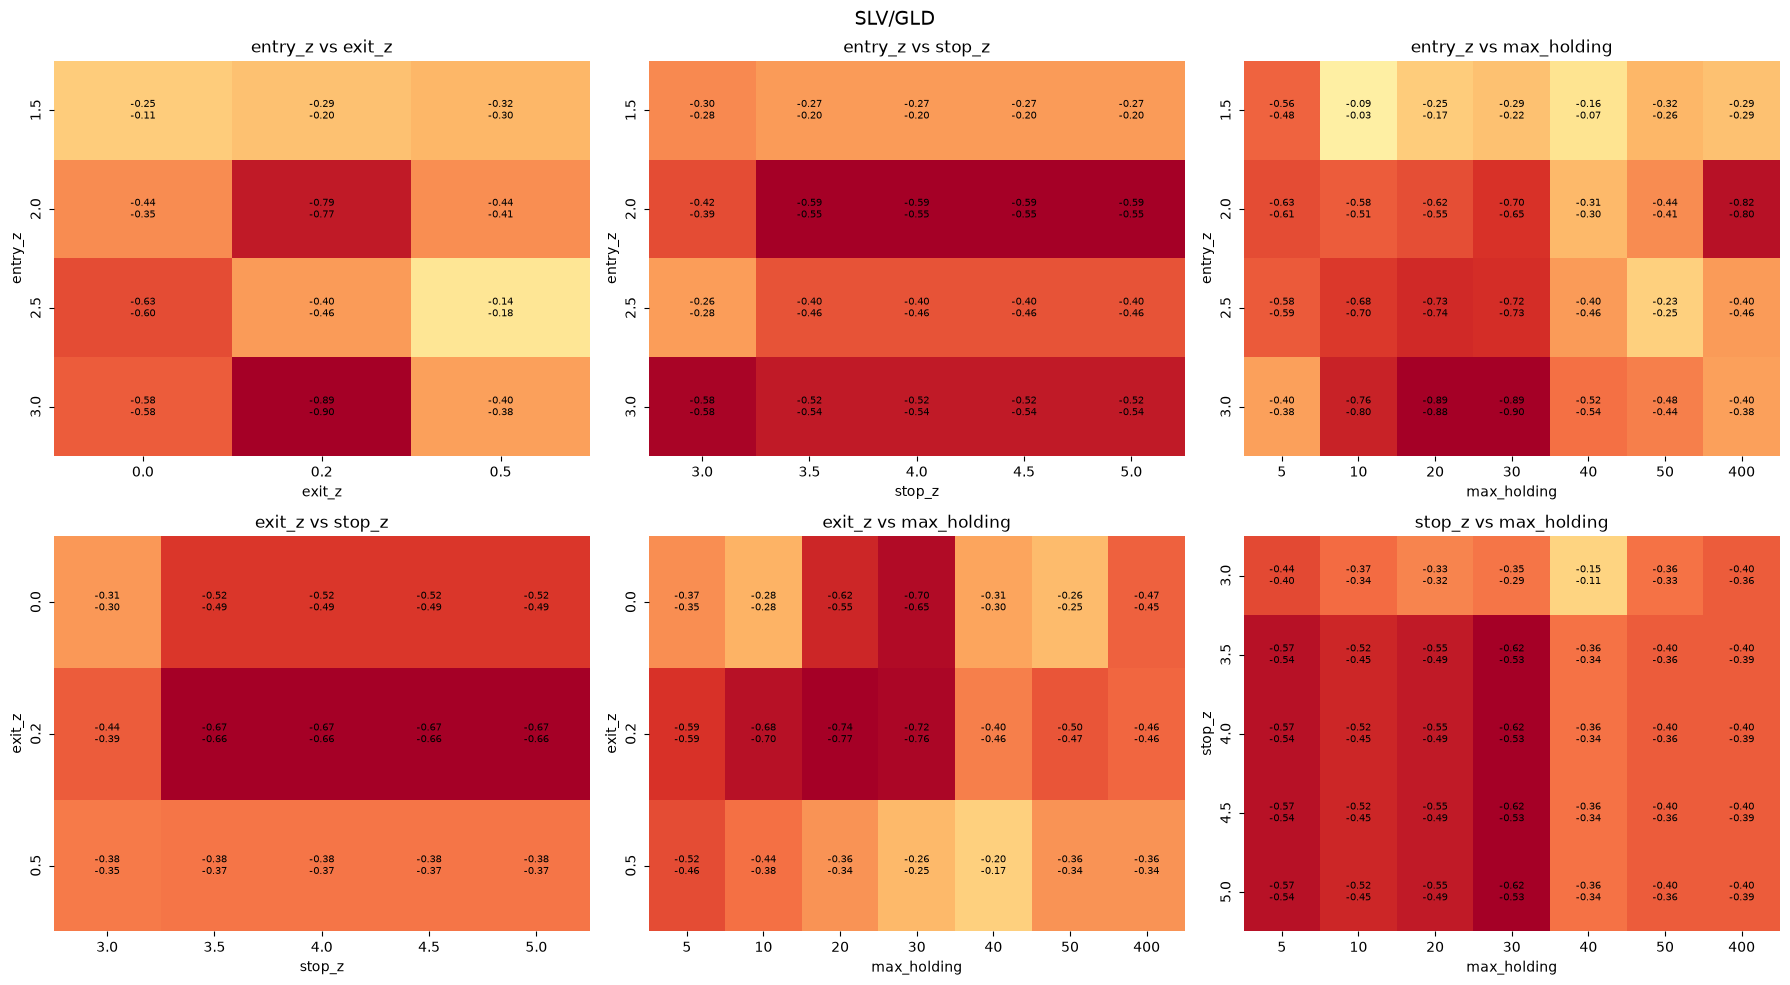

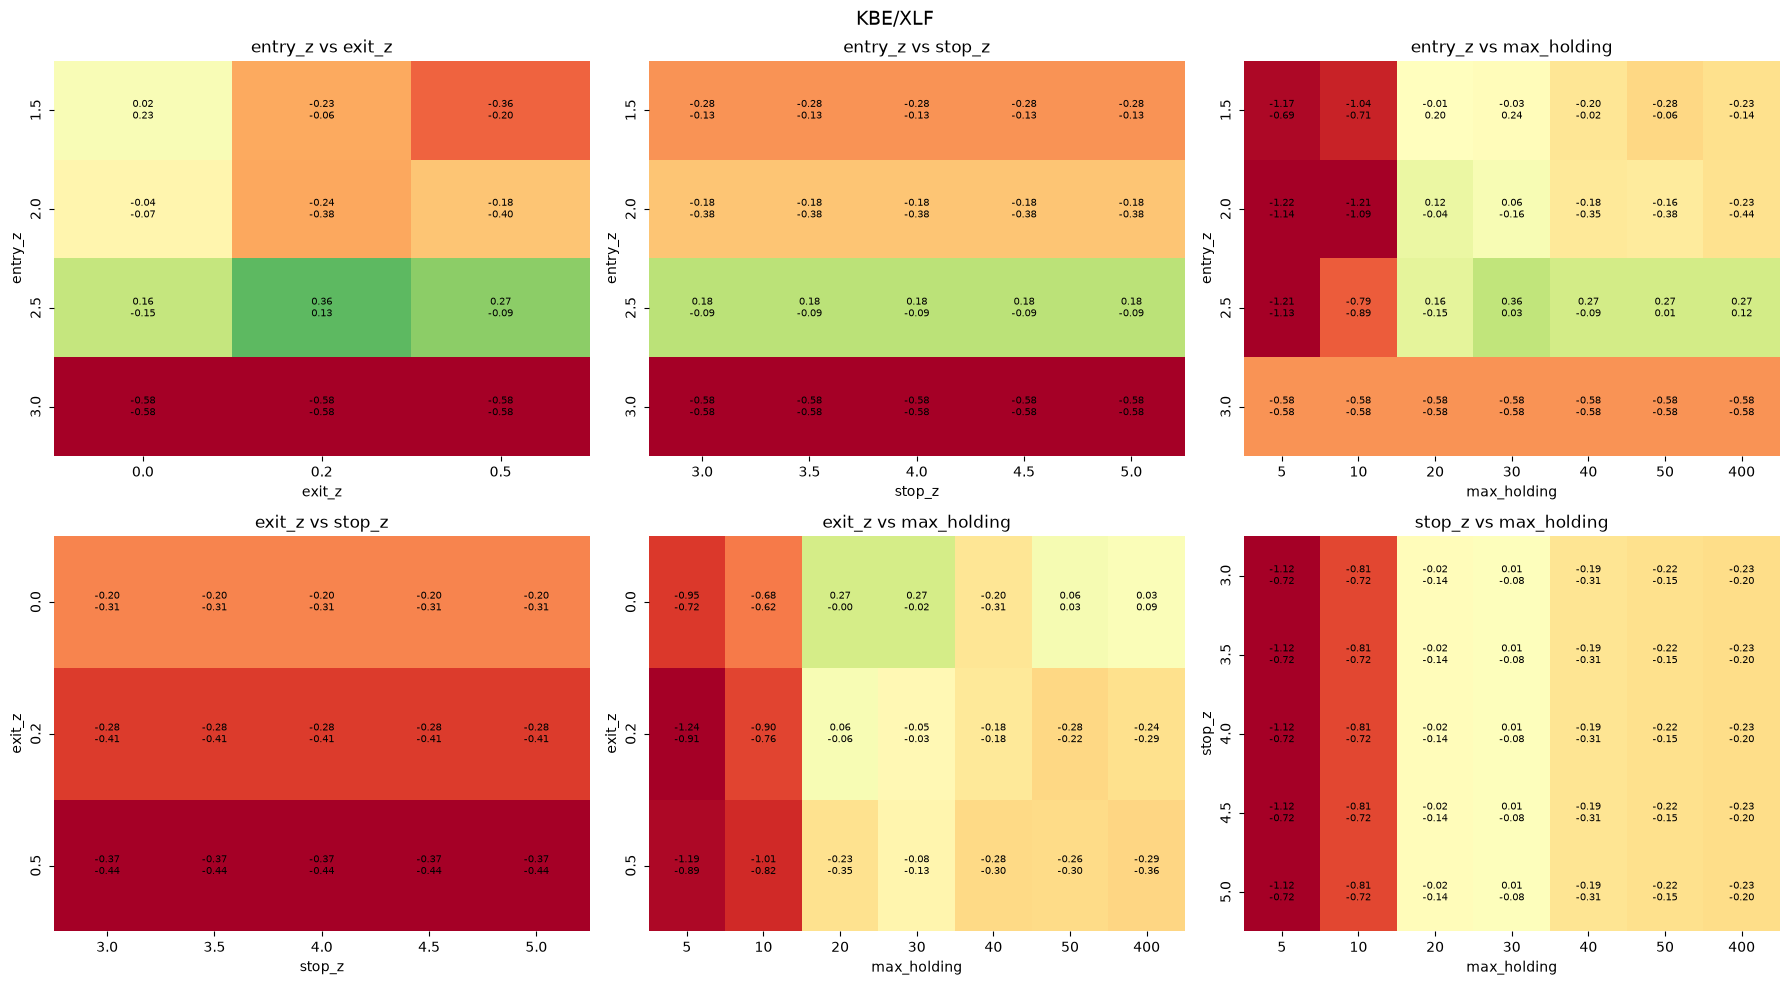

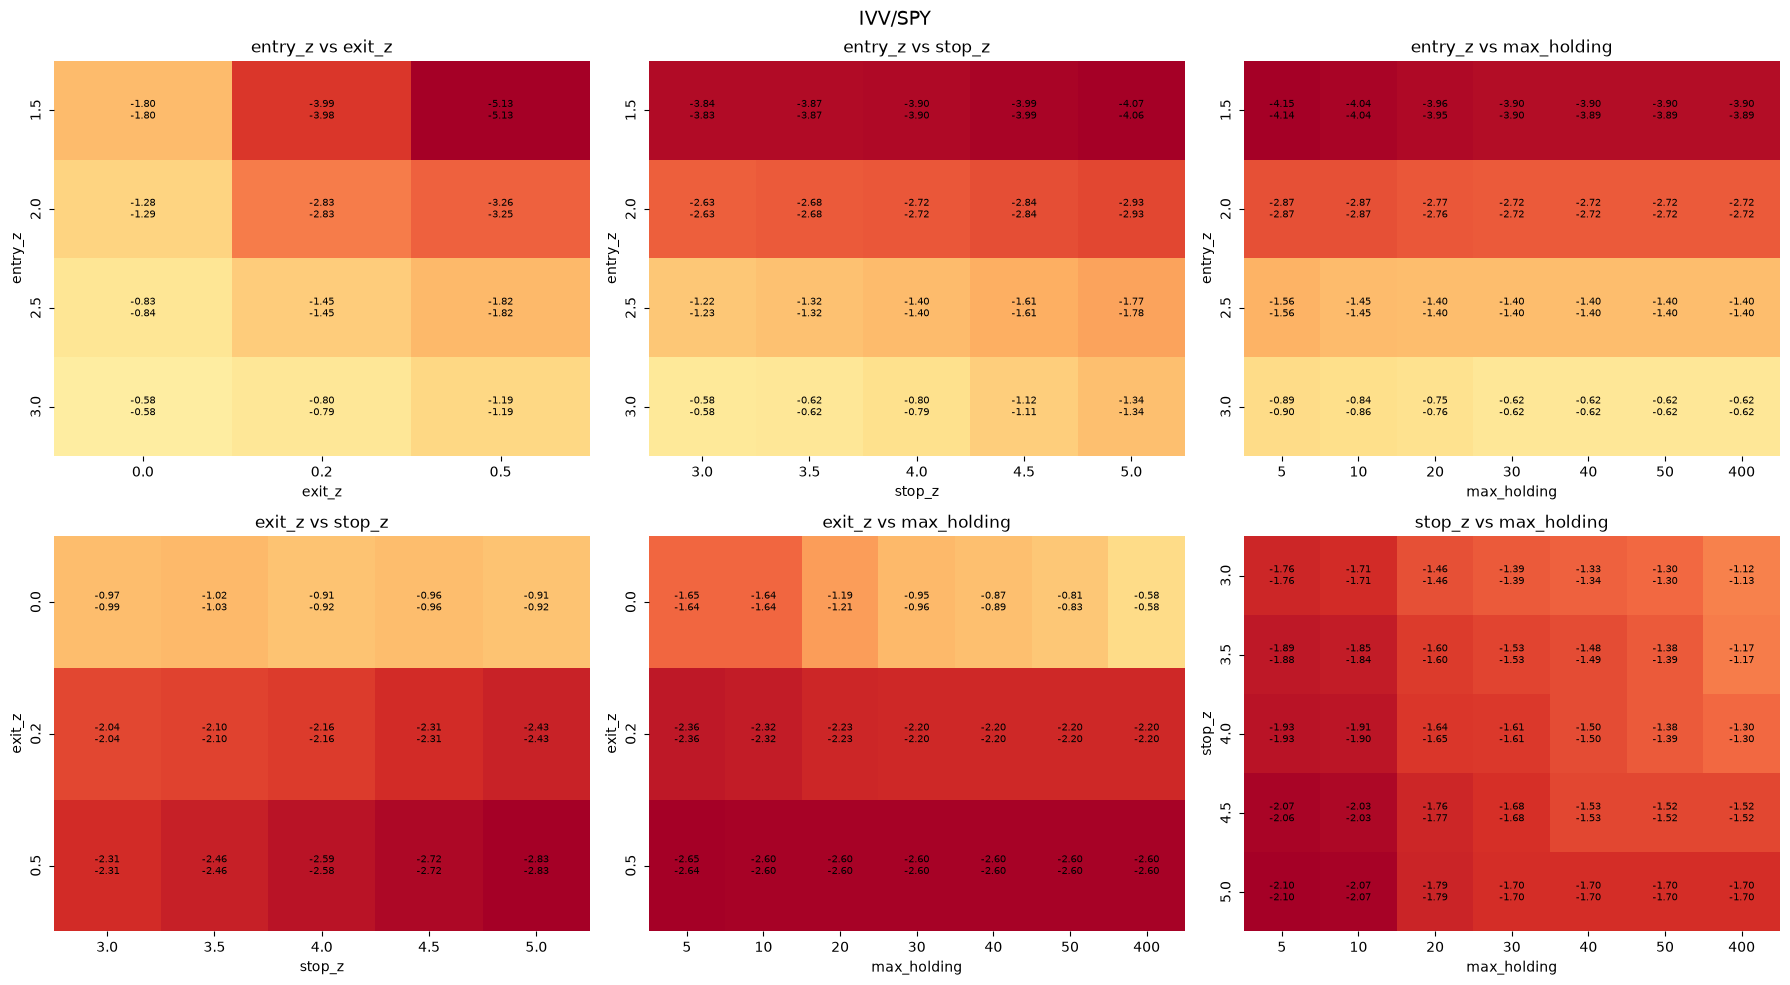

In [25]:
for y_pair, x_pair in [("IAU", "GDX"), ("GLD", "SLV"), ("XLF", "KBE"), ("SPY", "IVV")]:
    subset = df_grid[df_grid["pair"].apply(tuple) == (y_pair, x_pair)]
    
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    axs = axs.flatten()
    fig.suptitle(f"{x_pair}/{y_pair}", fontsize=14)
    
    for ax, (p1, p2) in zip(axs, param_pairs):
        # Aggregate over remaining params by taking median
        pivot_ols = subset.groupby([p1, p2])["sharpe_ols_with_garch_pos"].median().unstack(p2)
        pivot_kalman = subset.groupby([p1, p2])["sharpe_kalman_with_garch_pos"].median().unstack(p2)
        
        # Color by OLS Sharpe
        sns.heatmap(pivot_ols, ax=ax, cmap="RdYlGn", center=0, annot=False, cbar=False)
        
        # Annotate with both values
        for i, row in enumerate(pivot_ols.index):
            for j, col in enumerate(pivot_ols.columns):
                ols_val = pivot_ols.loc[row, col]
                kal_val = pivot_kalman.loc[row, col]
                ax.text(j+0.5, i+0.5, f"{ols_val:.2f}\n{kal_val:.2f}",
                        ha='center', va='center', fontsize=7)
        
        ax.set_title(f"{p1} vs {p2}")
    
    plt.tight_layout()
    plt.show()